In [1]:
# ==========================================
# Cell 1: Imports & Setup
# ==========================================
%load_ext autoreload
%autoreload 2

# Python Standard Libraries
import os
import json
import time
from pathlib import Path

# PyTorch Core libraries
import torch
import torch.nn as nn                                                               # Neural Network Layers (RELU, Batch Norm., Dropout, Linear Layers & CCE)
from torch.utils.data import DataLoader                                             # Dataset & Dataloader handlers
from torch.utils.tensorboard import SummaryWriter                                   # Tensorboard
from torchvision import transforms                                                  # Preprocessing (Rotation, Brightness, Resizing, etc)

# External Libraries
import numpy as np                                                                  # Array operations and numerical computations
import pandas as pd                                                                 # Data manipulation and analysis (Excel, CSV)
import matplotlib.pyplot as plt                                                     # Data visualization

# Scikit-Learn Libraries 
from sklearn.model_selection import train_test_split                                # Train-Test Split w/ Stratification (Balanced)
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, f1_score     # Metrics for Model Evaluation

# Local Module Imports
import src.config as src_config         # cfg, CLASS_SCHEME, PATHS, set_num_workers(), detect_os_set_paths()
from src.config import cfg, CLASS_SCHEME
from src.utils import set_seed, set_backend_cudnn_behaviour, set_device, FocalLoss
from src.loaders import load_ham10000, load_isic2019, load_ph2, load_pad_ufes20
from src.dataset import SkinLesionDataset
from src.model import MultimodalSkinCancerModel
from src.training import EarlyStopping, train_one_epoch, evaluate
from src.evaluation import compute_metrics, predict_image

set_seed(42)
print("\nImports complete, seed set: 42")

# If trying to use cuda, downgrade your pytorch and locate your CUDA Compute, then install the respective pytorch release for your specification.
set_backend_cudnn_behaviour("deterministic")
device = set_device()


c:\Users\User1\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Imports complete, seed set: 42
cuDNN behaviour set to: deterministic
Device: cuda


In [3]:
# ==========================================
# Cell 2: Configure Run Directory
# ==========================================

CURRENT_DIR = Path(os.getcwd())
RUNS_DIR = CURRENT_DIR / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

while True:
    user_input = input(r"Enter your pre-existing training/run directory path if it exists. --- To generate a new directory type NO or NA.")
    
    match user_input.lower():
        case "no" | "na":
            # Assuming cfg is imported or defined earlier in your notebook cells
            DIR_NAME = RUNS_DIR / (time.strftime("%Y-%m-%d-%H-%M_") + cfg.model.backbone)
            DIR_NAME.mkdir(parents=True, exist_ok=True)
            print(f"New run directory created: {DIR_NAME}")
            break

        case "mahmoud" | "aci":
            DIR_NAME = r"C:\Users\User1\Documents\GitHub\CNN\V0.2\2026-03-02-23-28_efficientnet_b0"
            
        case _:
            input_path = Path(user_input)
            if (RUNS_DIR / input_path).is_dir():
                DIR_NAME = RUNS_DIR / input_path
            else:
                DIR_NAME = input_path.resolve()
    
    INPUT_DIR = Path(DIR_NAME).resolve()

    if not INPUT_DIR.exists() or not INPUT_DIR.is_dir():
        print(f"Error: The provided path '{DIR_NAME}' does not exist or is not a directory.")
        print(f"Run folders are stored in {RUNS_DIR}")
        print("Please try again or exit by pressing Ctrl+C\n")
        continue
    
    break

print(f"Files will be saved in {DIR_NAME}")

while True:
    print("\nIf your datasets folder are contained in a subfolder from where this file is stored, simply type the name of the subfolder (e.g. datasets)")
    user_input = input(r"Enter the parent dataset directory paths (That includes all the datasets, e.g., C:\Users\User1\Desktop\datasets)")

    match user_input.lower():
        case "maccy":
            # REPLACE the path below with your actual target directory for "maccy"
            PARENT_DIR = Path(r"C:\Users\User1\Desktop\datasets").resolve()
        case _:
            # If it's not "maccy", process the user's manual input normally
            PARENT_DIR = Path(user_input).resolve()

    # Validate inputted user path exists
    if not PARENT_DIR.exists() or not PARENT_DIR.is_dir():
        print(f"Error: The provided path '{PARENT_DIR}' does not exist or is not a directory.")
        print("Please try again or exit by pressing Ctrl+C\n")
        continue
    
    print(f"Targeting: {PARENT_DIR}")

    # Update config's DATA_ROOT and regenerate the PATHS dictionary
    src_config.DATA_ROOT = PARENT_DIR
    src_config.detect_os_set_paths() 
    print(f"Number of workers set to: {src_config.cfg.data.num_workers}")
    # Validation Logic
    print(f"{'=' * 40}")
    all_found = True
    for dataset, paths in src_config.PATHS.items():
        base = paths['base']

        if base.exists():
            print(f" {dataset}: Found")
            contents = [f.name for f in base.iterdir()][:5] 
            print(f"      Contents: {contents}...")
        else:
            print(f" {dataset}: NOT FOUND")
            all_found = False
    print(f"{'=' * 40}")

    # Exit loop if successful
    if all_found:
        print("All datasets parsed successfully! Proceeding...")
        break 
    
    print("Warning: Some datasets appear to be missing from this parent directory.")
    retry = input("Would you like to try entering a different path? (yes/no): ")
    
    match retry.lower():
        case "yes" | "y":
            print("\nRetrying...")
            continue
        case "no" | "n":
            confirmation = input("Are you sure? Type YES to proceed anyway, or NO to try another path: ")
            match confirmation.lower():
                case "yes" | "y":
                    print("Proceeding with missing directories. Expect errors during data loading.")
                    break
                case _:
                    print("\nRetrying...")
                    continue
        case _:
            print("\nUnrecognized input. Retrying path configuration...")
            continue

print(f"\nDatasets are set under: {PARENT_DIR}")


Files will be saved in C:\Users\User1\Documents\GitHub\CNN\V0.3\runs\2026-04-22-16-07_efficientnet_b1

If your datasets folder are contained in a subfolder from where this file is stored, simply type the name of the subfolder (e.g. datasets)
Targeting: C:\Users\User1\Desktop\datasets
Running on Windows & Using Windows Pathing, Update it as need be.

Number of workers set to: 0
 pad_ufes_20: Found
      Contents: ['imgs_part_1', 'imgs_part_2', 'imgs_part_3', 'metadata.csv']...
 ph2: Found
      Contents: ['PH2 Dataset images', 'PH2_dataset.txt', 'PH2_dataset.xlsx', 'Readme.txt']...
 ham10000: Found
      Contents: ['HAM10000_images_part_1', 'HAM10000_images_part_2', 'HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv']...
 isic_2019: Found
      Contents: ['ISIC_2019_Training_GroundTruth.csv', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Metadata.csv']...
All datasets parsed successfully! Proceeding...

Datasets are set under: C:\Users\User1\Desktop\datasets


In [4]:
# ==========================================
# Cell 3: Load Datasets
# ==========================================

print("Loading datasets...")

# Load each dataset independently
ham_df,  ham_image_paths  = load_ham10000()
isic_df, isic_image_paths = load_isic2019()
ph2_df,  ph2_image_paths  = load_ph2()
pad_df,  pad_image_paths  = load_pad_ufes20()

# Print summary of loaded datasets
print(f"\n{'Dataset':<15} {'Samples':>8}  Labels")
print("-" * 60)
for name, df in [("HAM10000", ham_df), ("ISIC 2019", isic_df), ("PH2", ph2_df), ("PAD-UFES-20", pad_df)]:
    labels = ', '.join(f"{l}:{c}" for l, c in df['label'].value_counts().items())
    print(f"{name:<15} {len(df):>8}  {labels}")


Loading datasets...

Dataset          Samples  Labels
------------------------------------------------------------
HAM10000           10015  nv:6705, mel:1113, bkl:1099, bcc:514, akiec:327, vasc:142, df:115
ISIC 2019          25331  nv:12875, mel:4522, bcc:3323, bkl:2624, akiec:867, scc:628, vasc:253, df:239
PH2                  200  nv:160, mel:40
PAD-UFES-20         2298  bcc:845, akiec:730, nv:244, bkl:235, scc:192, mel:52


In [5]:
# ==========================================
# Cell 4: Combine & Split
# ==========================================
standard_cols = ["image_id", "label", "age", "sex", "localization", "dataset"]
all_image_paths = {}
training_dfs = []

# --- Training Pool: HAM10000 + ISIC2019 ---
# These two dermoscopic datasets form the training/validation/test pool
for df, paths in [(ham_df, ham_image_paths), (isic_df, isic_image_paths)]:
    if len(df) > 0:
        for col in standard_cols:
            if col not in df.columns: df[col] = np.nan
        training_dfs.append(df[standard_cols].copy())
        all_image_paths.update(paths)
combined_df = pd.concat(training_dfs, ignore_index=True)


# --- External Test Sets ---
# PH2 and PAD-UFES-20 are held out entirely for cross-dataset evaluation
external_ph2_df = ph2_df[standard_cols].copy() if len(ph2_df) > 0 else pd.DataFrame()
external_pad_df = pad_df[standard_cols].copy() if len(pad_df) > 0 else pd.DataFrame()
if len(ph2_df) > 0: all_image_paths.update(ph2_image_paths)
if len(pad_df) > 0: all_image_paths.update(pad_image_paths)

# --- Stratified Split (70/15/15) ---
# Stratification ensures each class is proportionally represented in each split
train_df, temp_df = train_test_split(combined_df,   test_size=cfg.data.test_size, stratify=combined_df["label"],    random_state=42)
val_df, test_df   = train_test_split(temp_df,       test_size=cfg.data.val_split, stratify=temp_df["label"],        random_state=42)

# --- Class Weights (inverse frequency + malignancy boost) ---
# Compensates for class imbalance in the loss function: weight = N / (n_classes * count)
class_counts = train_df["label"].value_counts()
n_classes = len(class_counts)
class_weights = {cls: len(train_df) / (n_classes * cnt) for cls, cnt in class_counts.items()}

# Apply malignancy boost which increases the loss penalty for missing malignant lesions
MALIGNANT_CLASSES = {"mel", "bcc", "scc", "akiec"}
class_weights = {
    cls: w * (cfg.data.malignancy_boost if cls in MALIGNANT_CLASSES else 1.0)
    for cls, w in class_weights.items()
}

weights_tensor = torch.tensor([class_weights[c] for c in sorted(class_weights)])

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"Train: {len(train_df):,} (70%)  |  Val: {len(val_df):,} (15%)  |  Test: {len(test_df):,} (15%)")
print(f"External PH2: {len(external_ph2_df):,}  |  External PAD: {len(external_pad_df):,}")
print(f"\nClass weights: {', '.join(f'{c}={w:.2f}' for c, w in sorted(class_weights.items()))}")


Train: 24,742  |  Val: 5,302  |  Test: 5,302
Train: 24,742 (70%)  |  Val: 5,302 (15%)  |  Test: 5,302 (15%)
External PH2: 200  |  External PAD: 2,298

Class weights: akiec=4.99, bcc=1.55, bkl=1.19, df=12.47, mel=1.06, nv=0.23, scc=9.49, vasc=11.21


In [6]:
# ==========================================
# Cell 5: Transforms & DataLoaders
# ==========================================

# ImageNet normalization constants (required for pretrained EfficientNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

#TODO: IMPROVE AND ADD HAIR REMOVAL
# --- Training augmentation pipeline ---
# Applies geometric and photometric augmentations to increase training diversity
train_transform = transforms.Compose([
    transforms.Resize((cfg.data.img_size + 32, cfg.data.img_size + 32)),
    transforms.RandomCrop(cfg.data.img_size),
    transforms.RandomHorizontalFlip(p=cfg.aug.flip_p),
    transforms.RandomVerticalFlip(p=cfg.aug.flip_p),
    transforms.RandomRotation(degrees=cfg.aug.rotation),
    transforms.ColorJitter(brightness=cfg.aug.brightness, contrast=cfg.aug.contrast, saturation=cfg.aug.saturation, hue=cfg.aug.hue),
    transforms.RandomAffine(degrees=0, translate=(cfg.aug.translate[0], cfg.aug.translate[1]), scale=(cfg.aug.scale[0], cfg.aug.scale[1])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# --- Validation/test preprocessing pipeline ---
# Deterministic resize and normalization only (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((cfg.data.img_size, cfg.data.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Create training dataset first (fits label and localization encoders)
train_dataset = SkinLesionDataset(train_df, all_image_paths, train_transform)

# Share encoders from train_dataset to all other datasets for consistency
shared_le = train_dataset.label_encoder
shared_loc = train_dataset.loc_encoder

# Create remaining datasets using shared encoders
val_dataset   = SkinLesionDataset(val_df, all_image_paths, val_transform, label_encoder=shared_le, loc_encoder=shared_loc)
test_dataset  = SkinLesionDataset(test_df, all_image_paths, val_transform, label_encoder=shared_le, loc_encoder=shared_loc)
external_ph2_dataset = SkinLesionDataset(external_ph2_df, all_image_paths, val_transform, label_encoder=shared_le, loc_encoder=shared_loc) if len(external_ph2_df) > 0 else None
external_pad_dataset = SkinLesionDataset(external_pad_df, all_image_paths, val_transform, label_encoder=shared_le, loc_encoder=shared_loc) if len(external_pad_df) > 0 else None

# Wrap datasets in DataLoaders for batch iteration
loader_args = dict(batch_size=cfg.data.batch_size, num_workers=cfg.data.num_workers, pin_memory=True)
train_loader = DataLoader(train_dataset, shuffle=True,  **loader_args)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_args)
test_loader  = DataLoader(test_dataset,  shuffle=False, **loader_args)
external_ph2_loader = DataLoader(external_ph2_dataset, shuffle=False, **loader_args) if external_ph2_dataset else None
external_pad_loader = DataLoader(external_pad_dataset, shuffle=False, **loader_args) if external_pad_dataset else None

print("DataLoaders ready.")
print(f"   Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")
if external_ph2_loader: print(f"   PH2 External: {len(external_ph2_loader)} batches")
if external_pad_loader: print(f"   PAD External: {len(external_pad_loader)} batches")


DataLoaders ready.
   Train: 3093 batches | Val: 663 | Test: 663
   PH2 External: 25 batches
   PAD External: 288 batches


In [7]:
# ============================================================
# Cell 6: Save Preprocessed Data
# ============================================================
import pickle
from dataclasses import asdict
from datetime import datetime

print(f"{'=' * 20}")
RUN_PATH = Path(DIR_NAME)

try:
    # Create Directory
    RUN_PATH.mkdir(parents=True, exist_ok=True)
    print(f"Directory {RUN_PATH} targeted successfully")

    # Hyperparameter Storing with Patch Notes Logic
    config_path = RUN_PATH / "hyperparameters.json"
    current_dict = asdict(cfg)
    current_compare_dict = json.loads(json.dumps(current_dict))
    patch_notes = []

    # If the file already exists, let's compare existing values with current values
    if config_path.exists():
        with open(config_path, "r") as f:
            try:
                existing_data = json.load(f)
            except json.JSONDecodeError:
                existing_data = {}
        
        # Preserve any older patch notes
        if "patch_notes" in existing_data:
            patch_notes = existing_data["patch_notes"]
            
        # Extract just the raw configuration blocks to compare against
        existing_config = {k: v for k, v in existing_data.items() if k != "patch_notes"}
        
        differences = []
        # Compare inner keys across all config groups (e.g., current_dict["train"]["lr"])
        for group_name, group_vars in current_compare_dict.items():
            if group_name not in existing_config:
                differences.append(f"Added new config group '{group_name}'")
                continue
            
            if isinstance(group_vars, dict) and isinstance(existing_config[group_name], dict):
                for param, new_val in group_vars.items():
                    old_val = existing_config[group_name].get(param)
                    if old_val != new_val:
                        differences.append(f"'{group_name}.{param}': {old_val} -> {new_val}")
        
        # If we detected changes, log them dynamically
        if differences:
            timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            patch_notes.append({
                "timestamp": timestamp,
                "changes": differences
            })
            print(f"Updates detected in configuration. Overwriting file and attaching patch notes.")
            
    # Save the updated data, including our patch history
    data_to_save = current_dict.copy()
    if patch_notes:
        data_to_save["patch_notes"] = patch_notes
    with open(config_path, "w") as f:
        json.dump(data_to_save, f, indent=2)
    print(f"Hyperparameters saved to {config_path}")

    # Save split DataFrames to CSV for reproducibility
    train_df.to_csv(RUN_PATH / "train_df.csv", index=False)
    val_df.to_csv(RUN_PATH / "val_df.csv", index=False)
    test_df.to_csv(RUN_PATH / "test_df.csv", index=False)
    
    if len(external_ph2_df) > 0:
        external_ph2_df.to_csv(RUN_PATH / "external_ph2_df.csv", index=False)
    if len(external_pad_df) > 0:
        external_pad_df.to_csv(RUN_PATH / "external_pad_df.csv", index=False)

    print("Saved: train_df.csv, val_df.csv, test_df.csv, external_ph2_df.csv, external_pad_df.csv, config.pkl, image_paths.pkl")


except PermissionError:
    print(f"Permission denied: Unable to write to {RUN_PATH}")
except Exception as e:
    print(f"An error occurred: {e}")
print(f"{'=' * 20}\n")

# Save configuration and image paths for later inference
config = {
    "class_scheme": CLASS_SCHEME,
    "num_classes": len(CLASS_SCHEME),
    "img_size": cfg.data.img_size,
    "metadata_dim": train_dataset.get_metadata_dim(),
    "class_weights": class_weights,
    "weights_tensor": weights_tensor.numpy().tolist(),
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "external_ph2_size": len(external_ph2_df),
    "external_pad_size": len(external_pad_df)
}

with open(RUN_PATH / "config.pkl", "wb") as f:
    pickle.dump(config, f)
    
with open(RUN_PATH / "image_paths.pkl", "wb") as f:
    pickle.dump(all_image_paths, f)
    
print("Saved: config.pkl, image_paths.pkl")
print(f"\nPipeline complete. Training pool: {len(train_df) + len(val_df) + len(test_df):,} | Classes: {len(CLASS_SCHEME)} | Image size: {cfg.data.img_size}x{cfg.data.img_size}")


Directory C:\Users\User1\Documents\GitHub\CNN\V0.3\runs\2026-04-22-16-07_efficientnet_b1 targeted successfully
Hyperparameters saved to C:\Users\User1\Documents\GitHub\CNN\V0.3\runs\2026-04-22-16-07_efficientnet_b1\hyperparameters.json
Saved: train_df.csv, val_df.csv, test_df.csv, external_ph2_df.csv, external_pad_df.csv, config.pkl, image_paths.pkl

Saved: config.pkl, image_paths.pkl

Pipeline complete. Training pool: 35,346 | Classes: 8 | Image size: 484x484


Device: cuda
No checkpoint found, starting fresh.
Training on cuda | 35 epochs | LR=0.001
Backbone frozen for first 5 epochs



Epoch  1/35 Train Accuracy: 52.17| Train Loss: 1.5982 | Val Loss: 1.4060 | Val Acc: 57.6% | LR: 1.0e-03 | best! :D


Epoch  2/35 Train Accuracy: 55.90| Train Loss: 1.4745 | Val Loss: 1.3247 | Val Acc: 61.6% | LR: 9.9e-04 | best! :D


Epoch  3/35 Train Accuracy: 56.17| Train Loss: 1.4402 | Val Loss: 1.3211 | Val Acc: 64.2% | LR: 9.8e-04 | best! :D


Epoch  4/35 Train Accuracy: 57.26| Train Loss: 1.4066 | Val Loss: 1.2494 | Val Acc: 64.3% | LR: 9.7e-04 | best! :D


...

Epoch 31/35 Train Accuracy: 92.10| Train Loss: 0.1921 | Val Loss: 0.8433 | Val Acc: 86.7% | LR: 4.3e-06 | patience 6/10


Epoch 32/35 Train Accuracy: 92.02| Train Loss: 0.1833 | Val Loss: 0.8338 | Val Acc: 87.3% | LR: 2.4e-06 | patience 7/10


Epoch 33/35 Train Accuracy: 92.85| Train Loss: 0.1775 | Val Loss: 0.8325 | Val Acc: 87.2% | LR: 1.1e-06 | patience 8/10


Epoch 34/35 Train Accuracy: 92.91| Train Loss: 0.1578 | Val Loss: 0.8576 | Val Acc: 87.1% | LR: 2.7e-07 | patience 9/10


Epoch 35/35 Train Accuracy: 92.96| Train Loss: 0.1655 | Val Loss: 0.8435 | Val Acc: 87.2% | LR: 0.0e+00 | :( Early stop (best val_loss: 0.6611)

Training complete in 618.9 min
Best model saved to c:\Users\User1\Documents\GitHub\CNN\V0.3\runs\2026-04-22-16-07_efficientnet_b1\best_model.pth
Training history saved to c:\Users\User1\Documents\GitHub\CNN\V0.3\runs\2026-04-22-16-07_efficientnet_b1\training_history.json, refer to Tensorboard for the training curves & evals


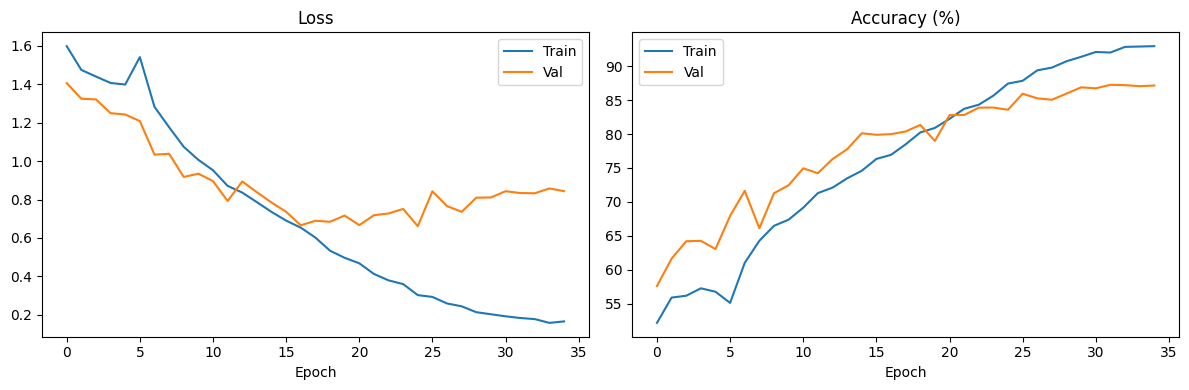

In [8]:
# ==========================================
# Cell 7: Train Model
# ==========================================

device = set_device()

# --- Checkpoint configuration ---
RESUME_FROM_CHECKPOINT = True  # Set True to resume from latest checkpoint
CHECKPOINT_PATH = RUN_PATH / "latest_checkpoint.pth"

# Model Initialization
model = MultimodalSkinCancerModel(
    num_classes=len(CLASS_SCHEME),
    metadata_dim=train_dataset.get_metadata_dim(),
    freeze_backbone=cfg.model.freeze_backbone
).to(device)

# Weighted cross-entropy loss to handle class imbalance
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))        # Either nn.CrossEntropyLoss(weight) or FocalLoss(weight,gamma=2.0)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.epochs)
early_stopping = EarlyStopping(patience=cfg.train.patience)

# --- Tensorboard Creation ---
writer = SummaryWriter(log_dir=RUN_PATH)

# Get class names from the training set's label encoder for reporting
all_class_names = list(train_dataset.label_encoder.classes_)

# --- Resume from checkpoint if requested ---
start_epoch = 1
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
if RESUME_FROM_CHECKPOINT and CHECKPOINT_PATH.exists():
    # Load checkpoint (weights_only=False needed for complex state dicts)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    
    # Rebuild optimizer with the correct parameter group structure for the resumed epoch
    if start_epoch > cfg.train.unfreeze_epoch:
        # Past warmup phase — backbone should be unfrozen with lower LR
        model.unfreeze_backbone()
        optimizer = torch.optim.AdamW([
            {"params": model.backbone.parameters(), "lr": cfg.train.lr * cfg.train.backbone_lr_factor},
            {"params": model.meta_branch.parameters()},
            {"params": model.classifier.parameters()}
        ], lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.epochs - cfg.train.unfreeze_epoch)
    else:
        # Still in warmup phase — only trainable (unfrozen) params
        optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.epochs)

    # Restore optimizer, scheduler, and early stopping state
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    early_stopping = EarlyStopping(patience=cfg.train.patience)
    early_stopping.best_loss = checkpoint["best_loss"]
    early_stopping.counter = checkpoint["es_counter"]
    early_stopping.best_state = checkpoint["es_best_state"]
    history = checkpoint["history"]
    print(f"Resumed from epoch {checkpoint['epoch']} (best val_loss: {early_stopping.best_loss:.4f})")
elif RESUME_FROM_CHECKPOINT:
    print("No checkpoint found, starting fresh.")

if start_epoch == 1:
    # Fresh start — create optimizer, scheduler, early_stopping from scratch
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.epochs)
    early_stopping = EarlyStopping(patience=cfg.train.patience)

print(f"Training on {device} | {cfg.train.epochs} epochs | LR={cfg.train.lr}")
print(f"Backbone frozen for first {cfg.train.unfreeze_epoch} epochs\n")

start_time = time.time()

# --- Training loop ---
for epoch in range(start_epoch, cfg.train.epochs + 1):

    # Unfreeze backbone after warmup phase
    if epoch == cfg.train.unfreeze_epoch + 1:
        model.unfreeze_backbone()
        
        # Reset optimizer with differential learning rates (backbone gets 10x lower LR)
        optimizer = torch.optim.AdamW([
            {"params": model.backbone.parameters(), "lr": cfg.train.lr * cfg.train.backbone_lr_factor},
            {"params": model.meta_branch.parameters()},
            {"params": model.classifier.parameters()}
        ], lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)

        # New cosine annealing schedule for remaining epochs
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.epochs - cfg.train.unfreeze_epoch)

    # Run one training and validation epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    # Move tensors to CPU implicitly for sklearn metric functions (GPU Moment)
    # cpu_labels, cpu_preds = val_labels.cpu(), val_preds.cpu()

    # Log metrics to Tensorboard
    writer.add_scalar('Epoch/Train_Loss', train_loss, epoch)
    writer.add_scalar('Epoch/Val_Loss', val_loss, epoch)
    writer.add_scalar('Epoch/Train_Accuracy', train_acc, epoch)
    writer.add_scalar('Epoch/Val_Accuracy', val_acc, epoch)
    writer.add_scalar('Epoch/Learning_Rate', optimizer.param_groups[0]['lr'], epoch)
    writer.add_scalar('Epoch/Balanced_Accuracy', balanced_accuracy_score(val_labels, val_preds), epoch)
    writer.add_scalar('Epoch/Weighted_F1', f1_score(val_labels, val_preds, average='weighted', zero_division=0), epoch)
    writer.add_scalar('Epoch/ES_Patience', early_stopping.counter, epoch)

    # --- Per-class accuracy on validation set (per epoch) ---
    for i, class_name in enumerate(all_class_names):
        mask = (val_labels == i)
        if mask.sum() > 0:
            class_acc = (val_preds[mask] == val_labels[mask]).mean() * 100
            writer.add_scalar(f'Class_Accuracy/{class_name}', class_acc, epoch)
    writer.flush()
    
    # Record metrics for plotting
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Print epoch summary with early stopping status
    lr_str = f"{optimizer.param_groups[0]['lr']:.1e}"
    print(f"Epoch {epoch:2d}/{cfg.train.epochs} Train Accuracy: {train_acc:.2f}| Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.1f}% | LR: {lr_str}", end="")

    # Check early stopping condition
    if early_stopping(val_loss, model):
        print(f" | :( Early stop (best val_loss: {early_stopping.best_loss:.4f})")
        break
    elif early_stopping.counter > 0:
        print(f" | patience {early_stopping.counter}/{cfg.train.patience}")
    else:
        print(f" | best! :D")

    # Save latest checkpoint (overwrite each epoch for crash recovery)
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history": history,
        "best_loss": early_stopping.best_loss,
        "es_counter": early_stopping.counter,
        "es_best_state": early_stopping.best_state,
    }, CHECKPOINT_PATH)

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.1f} min")

# Restore best model weights from early stopping
if early_stopping.best_state:
    model.load_state_dict(early_stopping.best_state)
    model.to(device)

# Save best model for evaluation
SAVE_PATH = RUN_PATH / "best_model.pth"
torch.save(model.state_dict(), SAVE_PATH)
print(f"Best model saved to {SAVE_PATH}")

# Save training history to JSON for later analysis
HISTORY_PATH = os.path.join(DIR_NAME, "training_history.json")
with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to {HISTORY_PATH}, refer to Tensorboard for the training curves & evals")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Val")
ax2.set_title("Accuracy (%)"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.show()

COMPREHENSIVE EVALUATION


Loaded: best_model.pth

──────────────────────────────────────────────────
Internal Test (5302 samples)
──────────────────────────────────────────────────


   Loss: 0.6508 | Accuracy: 83.3%
   Balanced Accuracy: 0.8005
   Weighted F1:       0.8387
              precision    recall  f1-score   support

       akiec       0.54      0.64      0.59       179
         bcc       0.86      0.91      0.88       576
         bkl       0.75      0.82      0.78       558
          df       0.89      0.79      0.84        53
         mel       0.65      0.85      0.74       846
          nv       0.96      0.83      0.89      2937
         scc       0.58      0.69      0.63        94
        vasc       0.85      0.86      0.86        59

    accuracy                           0.83      5302
   macro avg       0.76      0.80      0.78      5302
weighted avg       0.85      0.83      0.84      5302



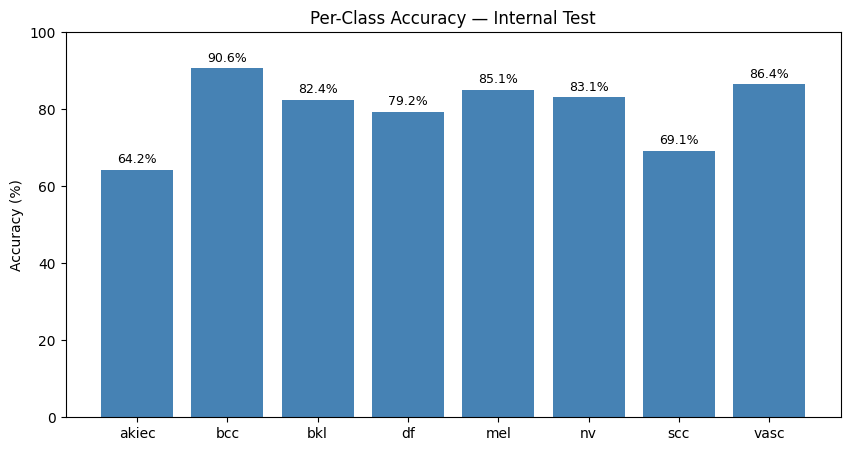

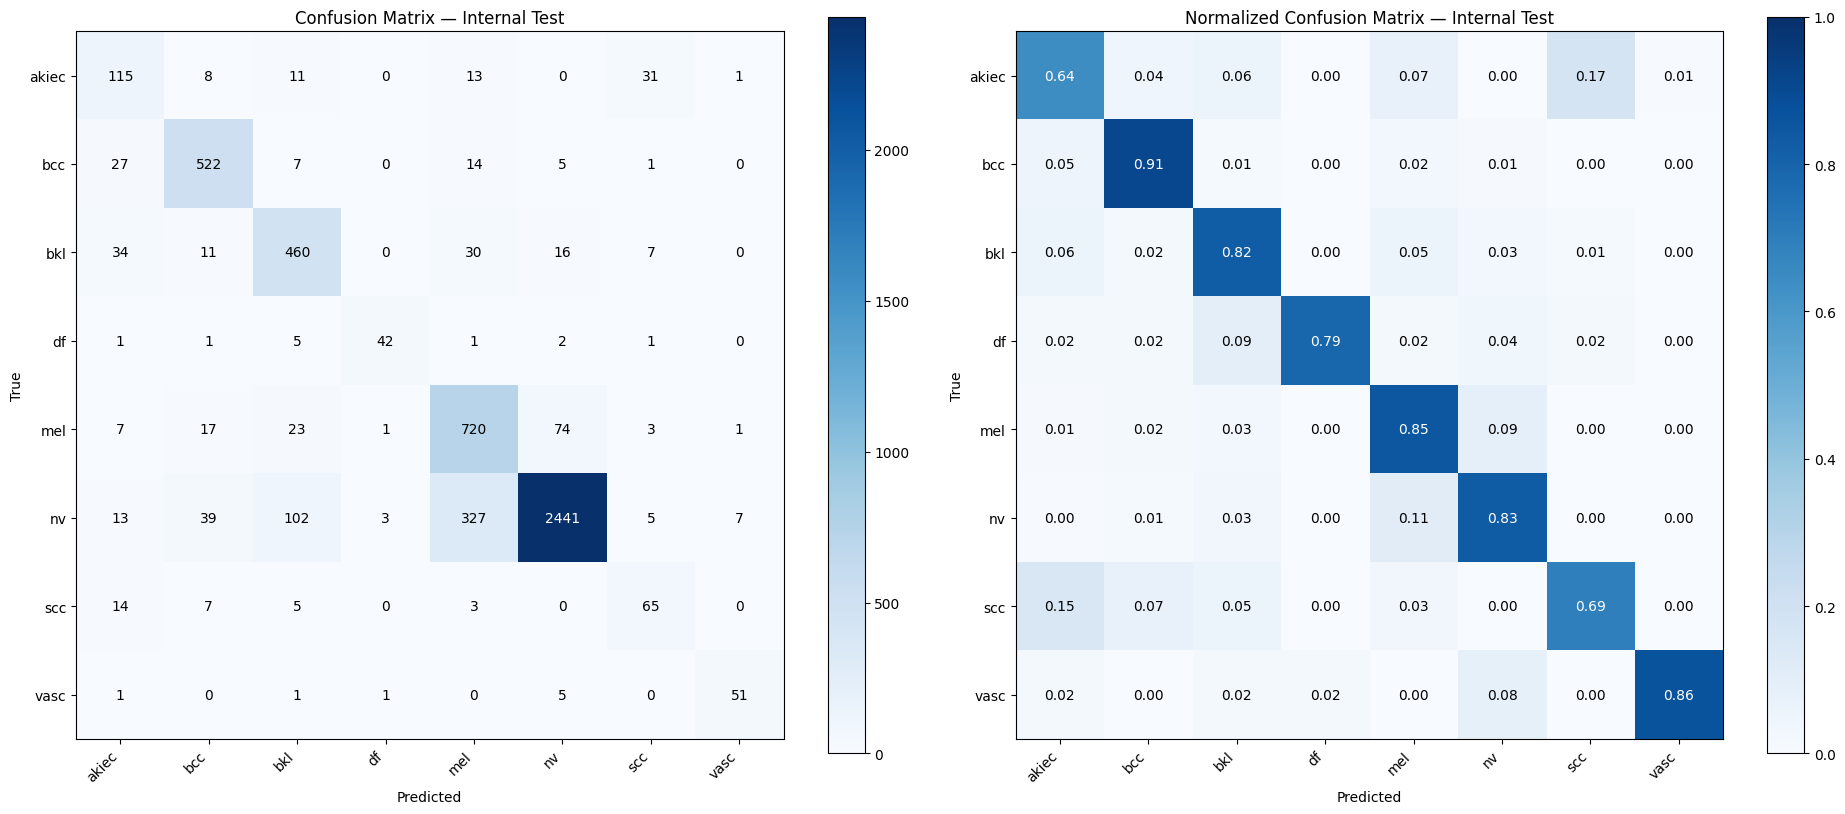


──────────────────────────────────────────────────
PH2 (Cross-dataset) (200 samples)
──────────────────────────────────────────────────


c:\Users\User1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


   Loss: 0.4171 | Accuracy: 81.0%
   Balanced Accuracy: 0.8250
   Weighted F1:       0.8406
              precision    recall  f1-score   support

         mel       0.61      0.85      0.71        40
          nv       0.96      0.80      0.87       160

   micro avg       0.86      0.81      0.83       200
   macro avg       0.78      0.82      0.79       200
weighted avg       0.89      0.81      0.84       200



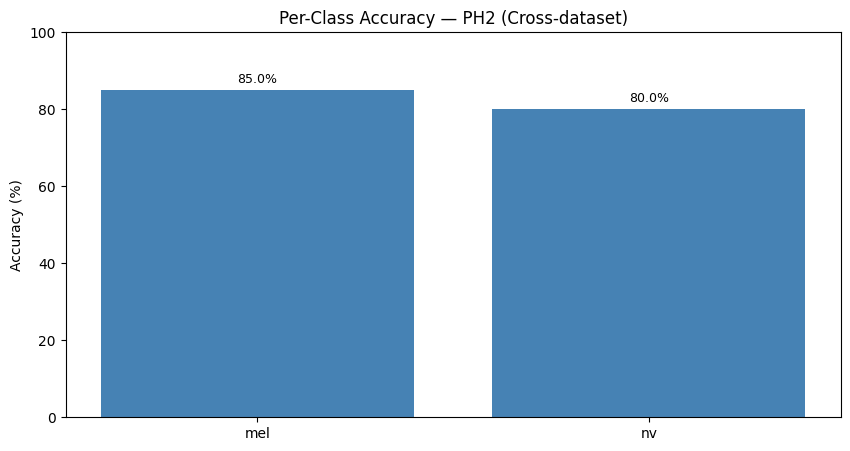

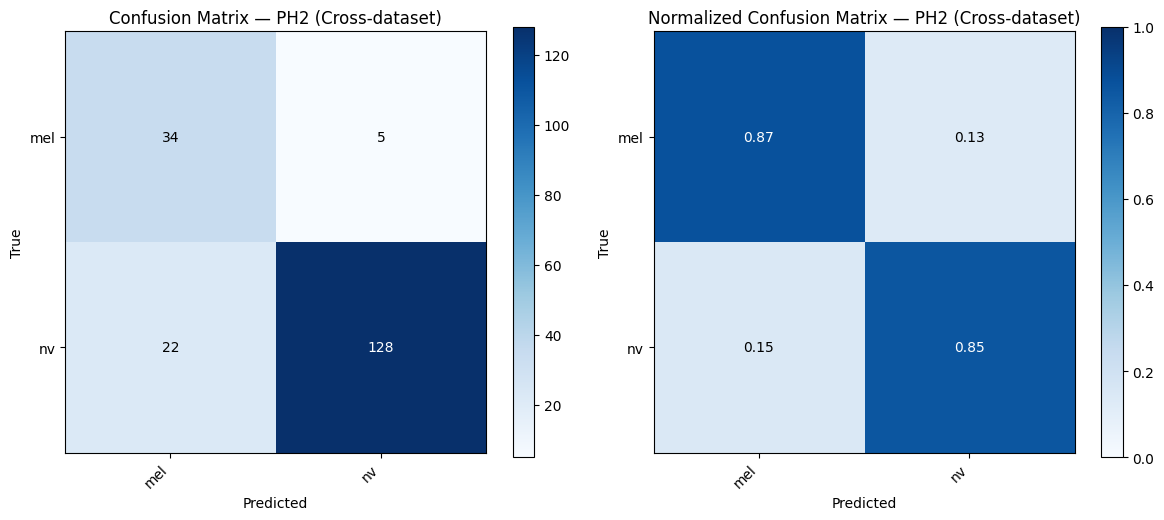


──────────────────────────────────────────────────
PAD-UFES-20 (Cross-domain) (2298 samples)
──────────────────────────────────────────────────


c:\Users\User1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


   Loss: 4.9503 | Accuracy: 33.8%
   Balanced Accuracy: 0.3320
   Weighted F1:       0.3654
              precision    recall  f1-score   support

       akiec       0.52      0.18      0.26       730
         bcc       0.59      0.45      0.51       845
         bkl       0.27      0.46      0.34       235
         mel       0.03      0.29      0.05        52
          nv       0.41      0.55      0.47       244
         scc       0.21      0.07      0.10       192

   micro avg       0.35      0.34      0.34      2298
   macro avg       0.34      0.33      0.29      2298
weighted avg       0.47      0.34      0.37      2298



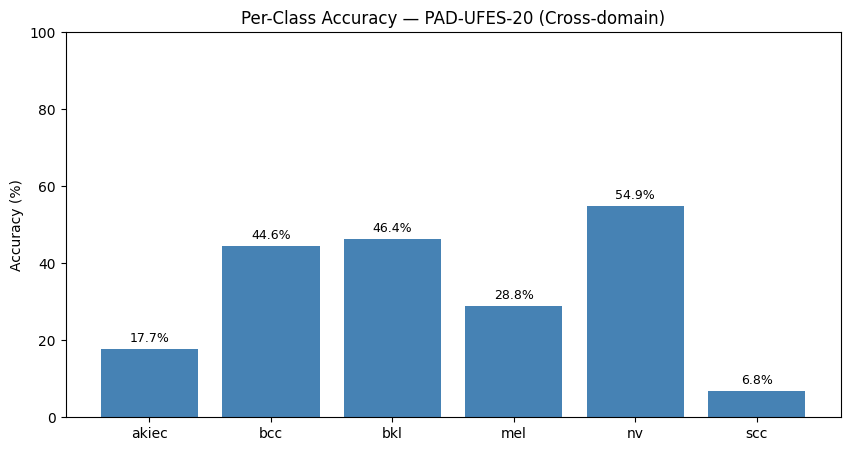

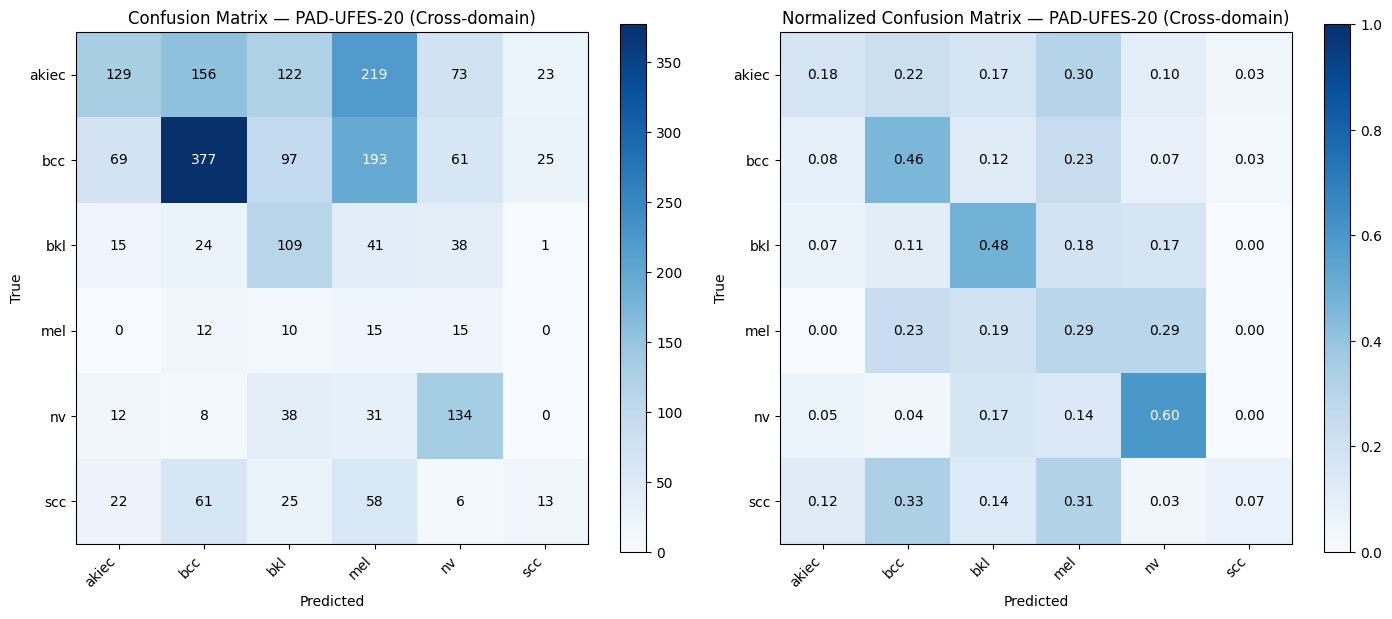


Test Set                          Acc  Bal.Acc     F1    Loss
------------------------------------------------------------
Internal Test                   83.3%  0.8005 0.839  0.6508
PH2 (Cross-dataset)             81.0%  0.8250 0.841  0.4171
PAD-UFES-20 (Cross-domain)      33.8%  0.3320 0.365  4.9503


In [9]:
# ==========================================
# Cell 8: Evaluation
# ==========================================

print("=" * 60)
print("COMPREHENSIVE EVALUATION")
print("=" * 60)

# --- Build the correctly-sized model for this run ---
model = MultimodalSkinCancerModel(
    num_classes=len(CLASS_SCHEME),
    metadata_dim=train_dataset.get_metadata_dim(),
    freeze_backbone=False   # Doesn't matter for evaluation
).to(device)

# Load best model from checkpoint for evaluation
CHECKPOINT_CANDIDATES = [
    (RUN_PATH / "best_model.pth",           "best"),
    (RUN_PATH / "latest_checkpoint.pth",    "latest")
]

for checkpoint_path, checkpoint_type in CHECKPOINT_CANDIDATES:
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        if checkpoint_type == "latest": model.load_state_dict(checkpoint["model_state_dict"])
        else: model.load_state_dict(checkpoint)
        print(f"Loaded: {checkpoint_path.name}")
        break
else:
    print(f"No checkpoint or best model found in {RUN_PATH}")
    raise SystemExit("Cannot train on an untrained model, move the file here or train the model.")

# Weighted cross-entropy loss to handle class imbalance
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))  # Either nn.CrossEntropy(weight=weights_tensor.to(device) or FocalLoss(weight, gamma=2.0))

# Get class names from the training set's label encoder for reporting
all_class_names = list(train_dataset.label_encoder.classes_)

# --- Tensorboard Creation ---
writer = SummaryWriter(log_dir=RUN_PATH)

# Define all test sets: internal test + external cross-dataset evaluations
results = {}
test_sets = [
    ("Internal Test", test_loader, test_dataset),
    ("PH2 (Cross-dataset)", external_ph2_loader, external_ph2_dataset),
    ("PAD-UFES-20 (Cross-domain)", external_pad_loader, external_pad_dataset)
]

# Evaluate on each test set
for name, loader, dataset in test_sets:
    if loader is None:
        print(f"\n\u26a0\ufe0f {name}: skipped (no data)")
        continue
    print(f"\n{'\u2500' * 50}")
    print(f"{name} ({len(dataset)} samples)")
    print('\u2500' * 50)

    # Run evaluation and compute comprehensive metrics
    # Note: labels and preds are returned as CPU Numpy arrays here!
    loss, acc, preds, labels = evaluate(model, loader, criterion, device)
    print(f"   Loss: {loss:.4f} | Accuracy: {acc:.1f}%")
    bal_acc, f1_w = compute_metrics(labels, preds, all_class_names)
    results[name] = {"accuracy": acc, "balanced_accuracy": bal_acc, "f1": f1_w, "loss": loss}

    # --- Per-class accuracy bar chart logging to TensorBoard ---
    class_accs = {}
    for i, class_name in enumerate(all_class_names):
        mask = (labels == i)  # Numpy boolean mask
        if mask.sum() > 0:
            # Numpy directly supports .mean() on booleans
            class_accs[class_name] = (preds[mask] == labels[mask]).mean() * 100
    fig_bar, ax_bar = plt.subplots(figsize=(10, 5))
    bars = ax_bar.bar(class_accs.keys(), class_accs.values(), color='steelblue')
    ax_bar.set_ylabel('Accuracy (%)')
    ax_bar.set_title(f'Per-Class Accuracy — {name}')
    ax_bar.set_ylim(0, 100)
    
    # Add value labels on top of each bar
    for bar, val in zip(bars, class_accs.values()):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    writer.add_figure(f'Class_Accuracy/{name}', fig_bar, 0, close=False)
    plt.show()
    plt.close(fig_bar)

    # --- Raw confusion matrix ---
    present_indices = sorted(set(labels))
    present_names = [all_class_names[i] for i in present_indices]
    cm = confusion_matrix(labels, preds, labels=present_indices)
    
    # Normalize confusion matrix by row (true class)
    cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    # Plot raw confusion matrix
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(12, len(present_names) * 2.4), max(5, len(present_names))))
    im = ax1.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax1.set_title(f"Confusion Matrix \u2014 {name}")
    ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
    ax1.set_xticks(range(len(present_names))); ax1.set_xticklabels(present_names, rotation=45, ha="right")
    ax1.set_yticks(range(len(present_names))); ax1.set_yticklabels(present_names)
    
    # Annotate each cell with its count
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax1.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.colorbar(im, ax=ax1)

    # Plot normalized confusion matrix
    im2 = ax2.imshow(cm_normalized, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=1)
    ax2.set_title(f"Normalized Confusion Matrix \u2014 {name}")
    ax2.set_xlabel("Predicted"); ax2.set_ylabel("True")
    ax2.set_xticks(range(len(present_names))); ax2.set_xticklabels(present_names, rotation=45, ha="right")
    ax2.set_yticks(range(len(present_names))); ax2.set_yticklabels(present_names)
    
    # Annotate each cell with its proportion
    for i in range(cm_normalized.shape[0]):
        for j in range(cm_normalized.shape[1]):
            ax2.text(j, i, f"{cm_normalized[i,j]:.2f}", ha="center", va="center",
                     color="white" if cm_normalized[i, j] > 0.5 else "black")
    plt.colorbar(im2, ax=ax2)
    writer.add_figure(f"Confusion Matrix/{name}", fig, 0, close=False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# --- Final summary table ---
print(f"\n{'=' * 60}")
print(f"{'Test Set':<30} {'Acc':>6} {'Bal.Acc':>8} {'F1':>6} {'Loss':>7}")
print(f"{'-' * 60}")
for name, r in results.items():
    print(f"{name:<30} {r['accuracy']:>5.1f}% {r['balanced_accuracy']:>7.4f} {r['f1']:>5.3f} {r['loss']:>7.4f}")
print(f"{'=' * 60}")

# Tensorboard Close Process
writer.close()


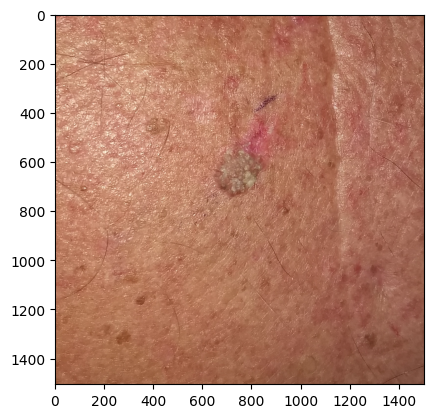

Prediction for: C:\Users\User1\Desktop\datasets\PAD-UFES-20\imgs_part_2\imgs_part_2\PAT_834_1574_276.png
----------------------------------------
  scc       70.8%  ███████████████████████████████████
  bkl       17.1%  ████████
  bcc        8.8%  ████
  vasc       1.8%  
  nv         1.1%  
  akiec      0.3%  
  df         0.2%  
  mel        0.0%  


{'scc': 70.779287815094,
 'bkl': 17.076395452022552,
 'bcc': 8.785315603017807,
 'vasc': 1.7747482284903526,
 'nv': 1.0787144303321838,
 'akiec': 0.34739417023956776,
 'df': 0.1569791231304407,
 'mel': 0.001167243954114383}

In [ ]:
# ==========================================
# Cell 9: Predict Single Image
# ==========================================
import cv2

model_path = r"C:\Users\User1\Documents\GitHub\CNN\V0.3\runs\2026-04-22-16-07_efficientnet_b1\best_model.pth"
model = MultimodalSkinCancerModel(
    num_classes=len(CLASS_SCHEME),
    metadata_dim=13,
    freeze_backbone=False
).to(device)

val_transform = transforms.Compose([
    transforms.Resize((484, 484)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Required for EfficientNet
])

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()
PathImg = r"C:\Users\User1\Desktop\datasets\PAD-UFES-20\imgs_part_2\imgs_part_2\PAT_834_1574_276.png"
img = cv2.imread(PathImg)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()



predict_image(
    PathImg, 
    model, 
    device, 
    transform=val_transform,
)
